# Reconstruction using Depth Anything v3 Pipeline

## Import Libraries

In [1]:
import glob
import os
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import sys
import open3d as o3d
sys.path.append("../Depth-Anything-3/src")
from depth_anything_3.api import DepthAnything3

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70


## Environment Setup and Visualization functions

In [2]:
def setup_paths(data_folder="SAMPLE_SCENE"):
    paths = {
        'data': "../data/images",
        'results': f"{data_folder}",
    }
    os.makedirs(paths['results'], exist_ok=True)
    return paths

def visualize_depth_and_confidence(images, depths, confidences, sample_idx=0):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(images[sample_idx])
    axes[0].set_title('RGB Image')
    axes[0].axis('off')

    axes[1].imshow(depths[sample_idx], cmap='turbo')
    axes[1].set_title('Depth Map')
    #axes[1].axis('off')

    axes[2].imshow(confidences[sample_idx], cmap='viridis')
    axes[2].set_title('Confidence Map')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

def visualize_point_cloud_open3d(points, colors=None, window_name="Point Cloud"):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    if colors is not None:
        pcd.colors = o3d.utility.Vector3dVector(colors)
    o3d.visualization.draw_geometries([pcd], window_name=window_name)

In [3]:
def visualize_point_cloud_matplotlib(points, colors=None, window_name="Point Cloud", max_points=100000):
    """
    Visualize a 3D point cloud using matplotlib for fast, non-blocking display in notebooks.
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    
    if len(points) > max_points:
        idx = np.random.choice(len(points), max_points, replace=False)
        points = points[idx]
        if colors is not None:
            colors = colors[idx]
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    if colors is not None:
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=colors, s=0.5)
    else:
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=0.5)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(window_name)
    plt.tight_layout()
    plt.show()

In [4]:
paths = setup_paths("../results/da3")
print(f"Project paths created: {paths}")

Project paths created: {'data': '../data/images', 'results': '../results/da3'}


## Load DA3 Model

In [5]:
def load_da3_model(model_name="depth-anything/DA3NESTED-GIANT-LARGE"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    model = DepthAnything3.from_pretrained(model_name)
    model.to(device)

    return model, device

In [6]:
model, device = load_da3_model()
print("Model loaded successfully.")

Using device: cuda


W0422 14:17:59.489000 3444 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
A matching Triton is not available, some optimizations will not be enabled
Traceback (most recent call last):
  File "c:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\.venv\Lib\site-packages\xformers\__init__.py", line 57, in _is_triton_available
    import triton  # noqa
    ^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'triton'


[INFO ] using SwiGLU layer as FFN
[INFO ] using MLP layer as FFN
Model loaded successfully.


## Load Images from folder

In [7]:
def load_images_from_folder(data_path, extensions=[".jpg", ".png", ".jpeg"]):
    image_files = []
    for ext in extensions:
        image_files.extend(glob.glob(os.path.join(data_path, f"*{ext}")))
    print(f"Found {len(image_files)} images in {data_path}")
    return image_files

def extract_frames_from_video(video_path, output_folder, sample_rate=3):
    os.makedirs(output_folder, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    saved_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % sample_rate == 0:
            output_path = os.path.join(output_folder, f"frame_{saved_count:05d}.png")
            cv2.imwrite(output_path, frame)
            saved_count += 1
        frame_count += 1

    cap.release()
    print(f"Extracted {saved_count} frames to {output_folder}")
    return output_folder

In [8]:
import sys
sys.path.append("../utils")
from imageSelector import select_equally_distributed_images

image_files = ["../data/images/frame_000000.png", "../data/images/frame_000025.png", "../data/images/frame_000051.png", "../data/images/frame_000073.png"] #select_equally_distributed_images("../data/images", 10)

## Run DA3 Inference for Depth and Poses and Apply Masks

In [9]:
def run_da3_inference(model, image_files, process_res_method="upper_bound_resize"):
    prediction = model.inference(
        image=image_files,
        infer_gs=True,
        process_res_method=process_res_method
    )
    torch.cuda.empty_cache()

    print(f"Depth maps shape: {prediction.depth.shape}")
    print(f"Extrinsics shape: {prediction.extrinsics.shape}")
    print(f"Intrinsics shape: {prediction.intrinsics.shape}")
    print(f"Confidences shape: {prediction.conf.shape}")

    return prediction

[INFO ] Processed Images Done taking 0.07398200035095215 seconds. Shape:  torch.Size([4, 3, 504, 420])
[INFO ] Selecting reference view using strategy: saddle_balanced
[INFO ] Model Forward Pass Done. Time: 52.895092248916626 seconds
[INFO ] Conversion to Prediction Done. Time: 0.004025697708129883 seconds
Depth maps shape: (4, 504, 420)
Extrinsics shape: (4, 3, 4)
Intrinsics shape: (4, 3, 3)
Confidences shape: (4, 504, 420)


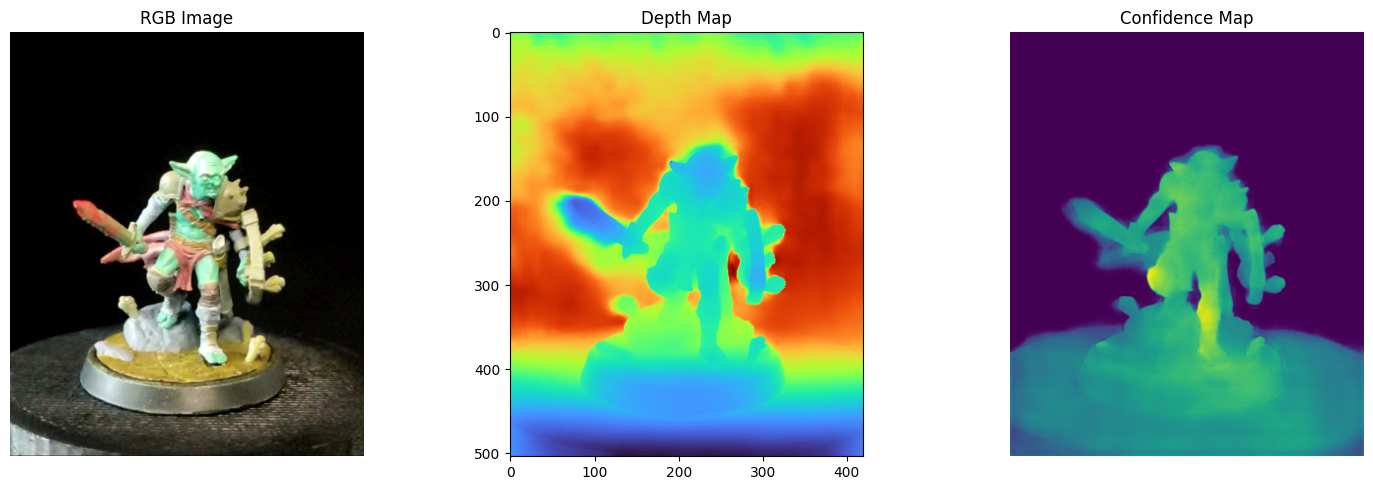

In [10]:
prediction = run_da3_inference(model, image_files)

visualize_depth_and_confidence(prediction.processed_images, prediction.depth, confidences=prediction.conf, sample_idx=0)

## Generate 3D Point Cloud from Depth Maps 

In [11]:
def depth_to_point_cloud(depth_map, rgb_image, intrinsics, extrinsics, conf_map=None, conf_thresh=0.5):
    h, w = depth_map.shape
    fx, fy = intrinsics[0, 0], intrinsics[1, 1]
    cx, cy = intrinsics[0, 2], intrinsics[1, 2]

    u, v = np.meshgrid(np.arange(w), np.arange(h))

    # Filter by confidence and valid depth (non-zero for masked regions)
    valid_mask = depth_map > 0  # Exclude masked regions (depth = 0)
    if conf_map is not None:
        valid_mask = valid_mask & (conf_map >= conf_thresh)
    
    u, v, depth_map = u[valid_mask], v[valid_mask], depth_map[valid_mask]
    
    # Handle RGBA vs RGB
    if rgb_image.shape[-1] == 4:
        rgb_image = rgb_image[..., :3]  # Drop alpha channel for colors
    rgb_image = rgb_image[valid_mask]
    
    x = (u - cx) * depth_map / fx
    y = (v - cy) * depth_map / fy
    z = depth_map

    points_cam = np.stack([x, y, z], axis=-1)

    R = extrinsics[:3, :3]
    t = extrinsics[:3, 3]
    points_world = (points_cam - t) @ R

    colors = rgb_image.astype(np.float32) / 255.0

    return points_world, colors

def merge_point_clouds(prediction, conf_thresh=0.5):
    all_points = []
    all_colors = []

    n_frames = len(prediction.depth)

    for i in range(n_frames):
        points, colors = depth_to_point_cloud(
            prediction.depth[i],
            prediction.processed_images[i],
            prediction.intrinsics[i],
            prediction.extrinsics[i],
            conf_map=prediction.conf[i],
            conf_thresh=conf_thresh
        )
        all_points.append(points)
        all_colors.append(colors)
    
    merged_points = np.vstack(all_points)
    merged_colors = np.vstack(all_colors)

    print(f"Merged point cloud has {len(merged_points)} points.")
    return merged_points, merged_colors

Merged point cloud has 846720 points.


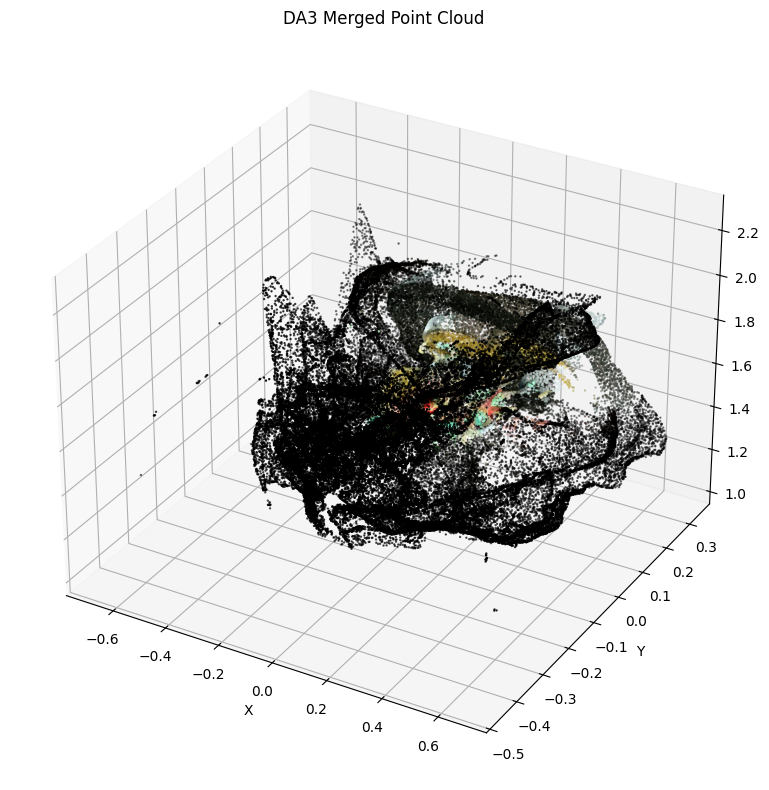

In [16]:
points_3d, colors_3d = merge_point_clouds(prediction, conf_thresh=0.7)
visualize_point_cloud_matplotlib(points_3d, colors_3d, window_name="DA3 Merged Point Cloud")

In [13]:
def clean_point_cloud(points_3d, colors_3d, nb_neighbors=20, std_ratio=2.0):
    from scipy.spatial import cKDTree

    tree = cKDTree(points_3d)
    distances, _ = tree.query(points_3d, k=nb_neighbors + 1, workers=-1)
    mean_distances = np.mean(distances[:, 1:], axis=1)
    global_mean = np.mean(mean_distances)
    global_std = np.std(mean_distances)

    distance_threshold = global_mean + (std_ratio * global_std)
    mask = mean_distances < distance_threshold
    return points_3d[mask], colors_3d[mask]

In [17]:
points_3d, colors_3d = clean_point_cloud(points_3d, colors_3d)

## Exporting point cloud

In [18]:
def export_point_cloud_ply(points, colors, filename):
    """
    Export a point cloud to a PLY file.
    Args:
        points: (N, 3) numpy array
        colors: (N, 3) numpy array, float [0,1] or uint8 [0,255]
        filename: output path
    """
    import trimesh
    if colors.max() <= 1.0:
        colors = (colors * 255).astype(np.uint8)
    pc = trimesh.PointCloud(points, colors=colors)
    pc.export(filename)
    print(f"✓ Point cloud exported to {filename}")

# Export merged point cloud
export_point_cloud_ply(points_3d, colors_3d,"../results/da3/Reconstruction.ply")

✓ Point cloud exported to ../results/da3/Reconstruction.ply
